In [ ]:
import tensorflow as tf
import keras
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [ ]:
# Load a small text dataset (IMDB Reviews)
dataset, dataset_info = tfds.load("imdb_reviews", as_supervised=True, with_info=True)
data_train, data_test = dataset["train"].batch(128), dataset["test"].batch(128)

In [ ]:
# Load a simple text model from Keras Applications
text_vectorizer = keras.layers.TextVectorization(max_tokens=10000, output_mode="int", output_sequence_length=256)

In [ ]:
# Prepare text vectorization
text_only_train = data_train.map(lambda x, y: x)
text_vectorizer.adapt(text_only_train)

In [ ]:
# Build the model
inputs = keras.Input(shape=(1,), dtype=tf.string)
x = text_vectorizer(inputs)
x = keras.layers.Embedding(input_dim=10000, output_dim=16)(x)
x = keras.layers.GlobalAveragePooling1D()(x)
x = keras.layers.Dense(16, activation="relu")(x)
x = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, x)

In [ ]:
# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Display sample text from dataset
sample_text, sample_label = next(iter(data_train.take(1)))
for i in range(3):  # Show 3 text samples
    print(f"Review {i+1}: {sample_text[i].numpy().decode('utf-8')}")
    print(f"Sentiment: {'Positive' if sample_label[i].numpy() == 1 else 'Negative'}\n")

Review 1: This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.
Sentiment: Negative

Review 2: I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film w

In [ ]:
# Train the model
history = model.fit(data_train, validation_data=data_test, epochs=3)  # Reduced epochs

Epoch 1/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.5772 - loss: 0.6839 - val_accuracy: 0.6906 - val_loss: 0.6057
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7756 - loss: 0.5426 - val_accuracy: 0.7980 - val_loss: 0.4441
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8417 - loss: 0.3920 - val_accuracy: 0.8382 - val_loss: 0.3740


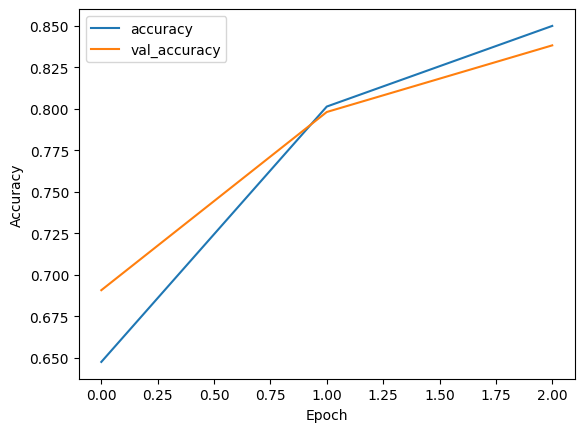

In [ ]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Summary of the Model Achievements
print("Summary of Achievements:")
print("- Implemented a simple text classification model for IMDB reviews.")
print("- Used TextVectorization for input preprocessing.")
print("- Trained an embedding-based model with pooling for classification.")
print("- Achieved a quick and efficient execution with 3 training epochs.")

Summary of Achievements:
- Implemented a simple text classification model for IMDB reviews.
- Used TextVectorization for input preprocessing.
- Trained an embedding-based model with pooling for classification.
- Achieved a quick and efficient execution with 3 training epochs.
